In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project root
PROJECT_ROOT = Path.cwd().parent

# Dataset path
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "LD2011_2014.txt"

print("Project root:", PROJECT_ROOT)
print("Dataset exists:", RAW_DATA_PATH.exists())
print("Dataset path:", RAW_DATA_PATH)

Project root: c:\Users\ADMIN\OneDrive\Desktop\Documents\ML-Projects\electricity-demand-forecasting
Dataset exists: True
Dataset path: c:\Users\ADMIN\OneDrive\Desktop\Documents\ML-Projects\electricity-demand-forecasting\data\raw\LD2011_2014.txt


In [2]:
sample = pd.read_csv(
    RAW_DATA_PATH,
    sep=";",
    decimal=",",
    nrows=1000,
)

sample.head()

,Unnamed: 0,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
0,2011-01-01 00:15:00,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2011-01-01 00:30:00,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2011-01-01 00:45:00,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2011-01-01 01:00:00,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2011-01-01 01:15:00,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
print("Sample shape:", sample.shape)
print("Number of columns:", len(sample.columns))

Sample shape: (1000, 371)
Number of columns: 371


In [4]:
print("Timestamp column:", sample.columns[0])
print("Number of clients:", len(sample.columns) - 1)

print("\nFirst 10 clients:")
print(sample.columns[1:11].tolist())

Timestamp column: Unnamed: 0
Number of clients: 370

First 10 clients:
['MT_001', 'MT_002', 'MT_003', 'MT_004', 'MT_005', 'MT_006', 'MT_007', 'MT_008', 'MT_009', 'MT_010']


In [5]:
sample["timestamp"] = pd.to_datetime(sample["Unnamed: 0"])

sample = sample.drop(columns=["Unnamed: 0"])

sample = sample.set_index("timestamp")

sample.head()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_344\577591882.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample["timestamp"] = pd.to_datetime(sample["Unnamed: 0"])


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
timestamp,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 00:30:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 00:45:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 01:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 01:15:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
client_columns = sample.columns

client_stats = pd.DataFrame({
    "mean": sample[client_columns].mean(),
    "std": sample[client_columns].std(),
    "min": sample[client_columns].min(),
    "max": sample[client_columns].max(),
    "zero_percentage": (sample[client_columns] == 0).mean() * 100,
})

client_stats.sort_values("mean", ascending=False).head(10)

,mean,std,min,max,zero_percentage
MT_196,21849.041667,7303.659506,8666.666667,33083.333333,0.0
MT_279,12935.747500,2909.793439,5941.666667,18990.833333,0.0
MT_208,6875.630252,2262.424351,1386.554622,9831.932773,0.0
MT_228,5248.315789,1610.101718,2210.526316,7210.526316,0.0
MT_194,2927.203390,840.346362,1372.881356,4114.406780,0.0
MT_220,2751.493671,1270.653886,1025.316456,4860.759494,0.0
MT_163,2656.857143,507.365868,1368.663594,4177.419355,0.0
MT_241,2601.283951,699.427119,1395.061728,4024.691358,0.0
MT_161,2135.419753,168.308227,1509.259259,2598.765432,0.0
MT_216,2107.710963,593.759700,1126.245847,2853.820598,0.0


In [7]:
client_stats.describe()

,mean,std,min,max,zero_percentage
count,370.000000,370.000000,370.000000,370.000000,370.000000
mean,305.276294,95.719014,127.813605,468.812092,57.605405
std,1435.995234,447.380832,589.787061,2150.301667,49.328989
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,100.000000
75%,176.500604,58.351907,68.614442,283.457285,100.000000
max,21849.041667,7303.659506,8666.666667,33083.333333,100.000000


In [8]:
client_stats.sort_values("mean", ascending=False).head(15)

,mean,std,min,max,zero_percentage
MT_196,21849.041667,7303.659506,8666.666667,33083.333333,0.0
MT_279,12935.747500,2909.793439,5941.666667,18990.833333,0.0
MT_208,6875.630252,2262.424351,1386.554622,9831.932773,0.0
MT_228,5248.315789,1610.101718,2210.526316,7210.526316,0.0
MT_194,2927.203390,840.346362,1372.881356,4114.406780,0.0
MT_220,2751.493671,1270.653886,1025.316456,4860.759494,0.0
MT_163,2656.857143,507.365868,1368.663594,4177.419355,0.0
MT_241,2601.283951,699.427119,1395.061728,4024.691358,0.0
MT_161,2135.419753,168.308227,1509.259259,2598.765432,0.0
MT_216,2107.710963,593.759700,1126.245847,2853.820598,0.0


In [9]:
client_stats.sort_values("max", ascending=False).head(15)

,mean,std,min,max,zero_percentage
MT_196,21849.041667,7303.659506,8666.666667,33083.333333,0.0
MT_279,12935.747500,2909.793439,5941.666667,18990.833333,0.0
MT_208,6875.630252,2262.424351,1386.554622,9831.932773,0.0
MT_228,5248.315789,1610.101718,2210.526316,7210.526316,0.0
MT_220,2751.493671,1270.653886,1025.316456,4860.759494,0.0
MT_163,2656.857143,507.365868,1368.663594,4177.419355,0.0
MT_194,2927.203390,840.346362,1372.881356,4114.406780,0.0
MT_241,2601.283951,699.427119,1395.061728,4024.691358,0.0
MT_323,1746.992195,631.131930,784.024390,3305.000000,0.0
MT_276,1910.857723,766.102274,704.257426,3250.396040,0.0


In [10]:
client_stats.sort_values("zero_percentage", ascending=False).head(20)

,mean,std,min,max,zero_percentage
MT_370,0.0,0.0,0.0,0.0,100.0
MT_001,0.0,0.0,0.0,0.0,100.0
MT_354,0.0,0.0,0.0,0.0,100.0
MT_353,0.0,0.0,0.0,0.0,100.0
MT_352,0.0,0.0,0.0,0.0,100.0
MT_351,0.0,0.0,0.0,0.0,100.0
MT_350,0.0,0.0,0.0,0.0,100.0
MT_349,0.0,0.0,0.0,0.0,100.0
MT_348,0.0,0.0,0.0,0.0,100.0
MT_347,0.0,0.0,0.0,0.0,100.0


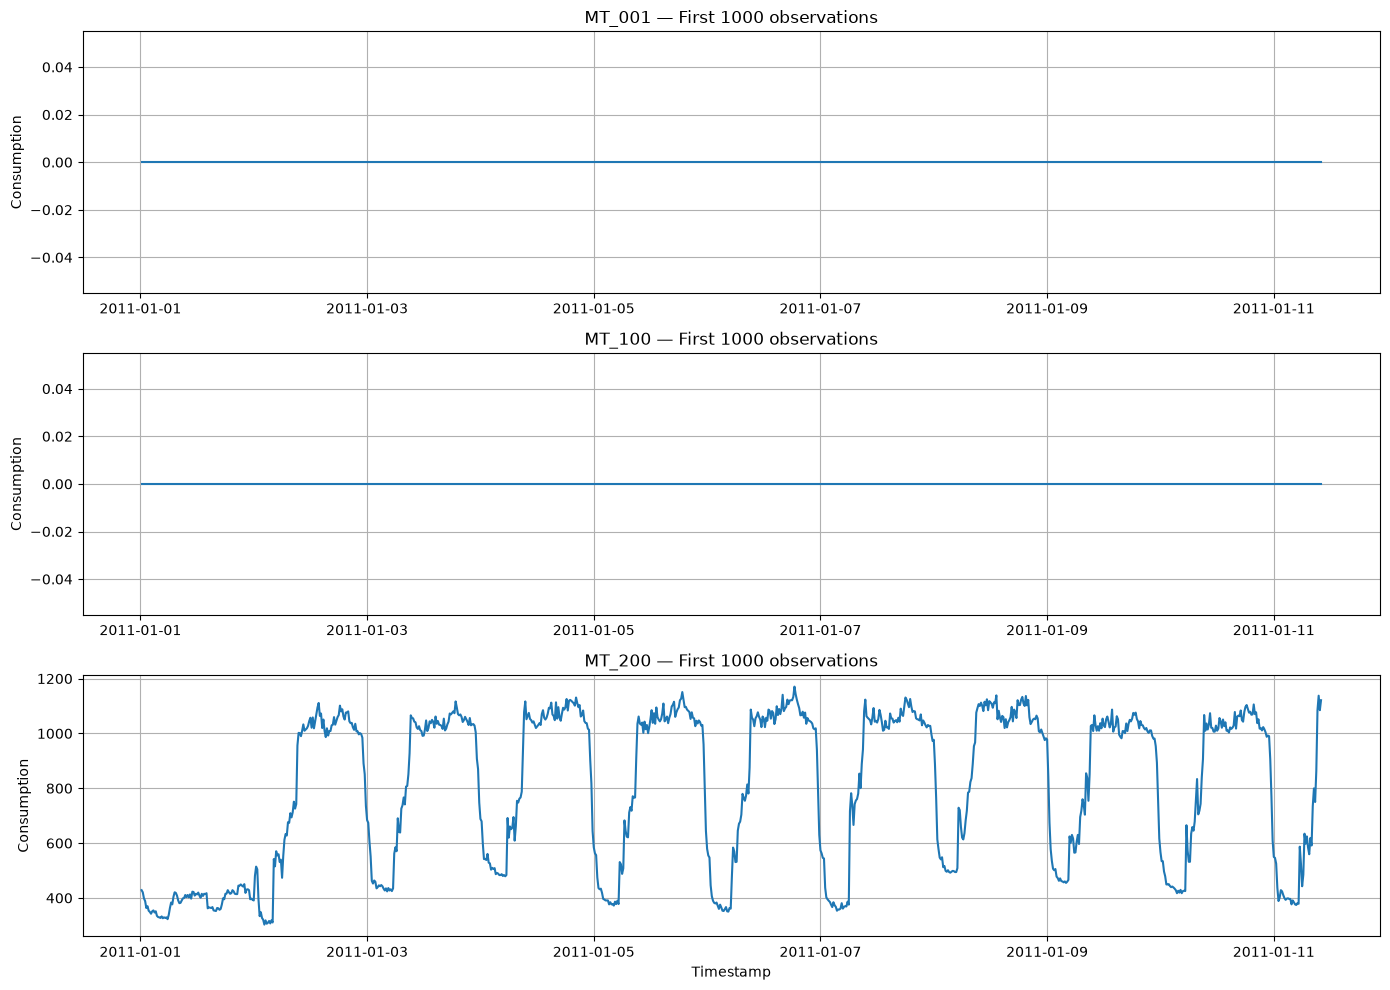

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

clients_to_plot = ["MT_001", "MT_100", "MT_200"]

for ax, client in zip(axes, clients_to_plot):
    ax.plot(sample.index, sample[client])
    ax.set_title(f"{client} — First 1000 observations")
    ax.set_ylabel("Consumption")
    ax.grid(True)

axes[-1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

In [12]:
CHUNK_SIZE = 10_000

client_columns = [f"MT_{i:03d}" for i in range(1, 371)]

# Running statistics
sum_values = pd.Series(0.0, index=client_columns)
sum_squared = pd.Series(0.0, index=client_columns)
count_values = pd.Series(0, index=client_columns)
zero_counts = pd.Series(0, index=client_columns)
min_values = pd.Series(np.inf, index=client_columns)
max_values = pd.Series(-np.inf, index=client_columns)

first_nonzero_timestamp = pd.Series(
    pd.NaT,
    index=client_columns,
    dtype="datetime64[ns]"
)

total_rows = 0

for chunk_number, chunk in enumerate(
    pd.read_csv(
        RAW_DATA_PATH,
        sep=";",
        decimal=",",
        chunksize=CHUNK_SIZE,
    ),
    start=1,
):
    timestamps = pd.to_datetime(chunk.iloc[:, 0])

    data = chunk.iloc[:, 1:]

    sum_values += data.sum()
    sum_squared += (data ** 2).sum()
    count_values += data.count()
    zero_counts += (data == 0).sum()

    min_values = np.minimum(min_values, data.min())
    max_values = np.maximum(max_values, data.max())

    # Find the first non-zero timestamp for each client
    for client in client_columns:
        if pd.isna(first_nonzero_timestamp[client]):
            nonzero_indices = data.index[data[client] > 0]

            if len(nonzero_indices) > 0:
                first_nonzero_timestamp[client] = timestamps.loc[
                    nonzero_indices[0]
                ]

    total_rows += len(chunk)

    print(f"Processed {total_rows:,} rows")

client_full_stats = pd.DataFrame({
    "mean": sum_values / count_values,
    "std": np.sqrt(
        (sum_squared / count_values)
        - (sum_values / count_values) ** 2
    ),
    "min": min_values,
    "max": max_values,
    "zero_percentage": (zero_counts / count_values) * 100,
    "first_nonzero": first_nonzero_timestamp,
})

client_full_stats.head()

Processed 10,000 rows
Processed 20,000 rows
Processed 30,000 rows
Processed 40,000 rows
Processed 50,000 rows
Processed 60,000 rows
Processed 70,000 rows
Processed 80,000 rows
Processed 90,000 rows
Processed 100,000 rows
Processed 110,000 rows
Processed 120,000 rows
Processed 130,000 rows
Processed 140,000 rows
Processed 140,256 rows


,mean,std,min,max,zero_percentage,first_nonzero
MT_001,3.970785,5.983944,0.0,48.223350,29.049025,2012-01-01 00:15:00
MT_002,20.768480,13.272368,0.0,115.220484,24.985740,2012-01-01 00:15:00
MT_003,2.918308,11.014417,0.0,151.172893,25.417807,2012-01-01 00:15:00
MT_004,82.184490,58.248184,0.0,321.138211,24.992157,2012-01-01 00:15:00
MT_005,37.240309,26.461233,0.0,150.000000,24.991444,2012-01-01 00:15:00


In [13]:
active_clients = client_full_stats[
    client_full_stats["mean"] > 0
]

inactive_clients = client_full_stats[
    client_full_stats["mean"] == 0
]

print("Total clients:", len(client_full_stats))
print("Active clients:", len(active_clients))
print("Inactive clients:", len(inactive_clients))

Total clients: 370
Active clients: 370
Inactive clients: 0


In [14]:
client_full_stats.sort_values("first_nonzero").head(20)

,mean,std,min,max,zero_percentage,first_nonzero
MT_246,608.014264,184.352315,0.000000,1236.887967,0.068446,2011-01-01 00:15:00
MT_226,483.897344,125.337806,0.000000,955.779674,0.039214,2011-01-01 00:15:00
MT_225,337.558575,108.320294,1.658537,668.614634,0.000000,2011-01-01 00:15:00
MT_223,336.210225,412.869009,0.000000,1541.333333,56.797570,2011-01-01 00:15:00
MT_222,946.283719,347.676081,0.000000,2045.333333,0.009982,2011-01-01 00:15:00
MT_221,158.689616,58.882783,0.000000,369.599167,0.011408,2011-01-01 00:15:00
MT_220,2951.449898,1229.483170,0.000000,7075.949367,0.010695,2011-01-01 00:15:00
MT_219,509.516822,193.259636,0.000000,1234.408602,0.058465,2011-01-01 00:15:00
MT_227,272.229800,95.814950,0.000000,549.641760,0.012834,2011-01-01 00:15:00
MT_218,1300.449095,390.410608,0.000000,2378.071834,0.017825,2011-01-01 00:15:00


In [15]:
client_full_stats.sort_values("first_nonzero").tail(20)

,mean,std,min,max,zero_percentage,first_nonzero
MT_179,20.279722,36.875366,0.0,154.619247,74.264203,2013-12-20 00:15:00
MT_120,9.609596,18.216621,0.0,95.861708,75.909765,2014-01-14 00:15:00
MT_106,12.313605,25.726174,0.0,148.148148,75.909765,2014-01-14 00:15:00
MT_107,4.059164,8.463041,0.0,68.015739,75.909765,2014-01-14 00:15:00
MT_121,27.650903,57.718703,0.0,619.815668,75.909765,2014-01-14 00:15:00
MT_110,5.663001,15.098150,0.0,215.608466,75.909765,2014-01-14 00:15:00
MT_108,7.155609,14.951678,0.0,131.318681,75.909765,2014-01-14 00:15:00
MT_113,7.732166,14.300749,0.0,72.289157,75.909765,2014-01-14 00:15:00
MT_115,5.649265,11.471308,0.0,84.914182,75.920460,2014-01-14 00:15:00
MT_122,5.380452,10.781735,0.0,71.606476,75.909765,2014-01-14 00:15:00


In [16]:
client_full_stats.describe()

,mean,std,min,max,zero_percentage,first_nonzero
count,370.000000,370.000000,370.000000,370.000000,370.000000,370
mean,528.532277,316.601600,0.507671,1750.244236,20.151071,2011-10-08 08:48:19.459459328
min,0.818058,2.260770,0.000000,22.613065,0.000000,2011-01-01 00:15:00
25%,41.895166,29.872933,0.000000,167.863408,0.008734,2011-01-01 00:15:00
50%,106.694350,57.757234,0.000000,315.047798,24.991444,2012-01-01 00:15:00
75%,301.967730,129.807294,0.000000,806.285248,25.006595,2012-01-01 00:15:00
max,37607.987537,38691.816899,15.243902,192800.000000,88.637919,2014-07-18 00:15:00
std,2416.149483,2118.131009,1.555571,11034.768047,22.214166,NaN


In [17]:
client_full_stats.sort_values(
    "mean",
    ascending=False
).head(15)

,mean,std,min,max,zero_percentage,first_nonzero
MT_362,37607.987537,38691.816899,0.000000,192800.000000,25.038501,2012-01-01 00:15:00
MT_196,20744.150874,7339.081784,0.000000,78541.666667,0.015686,2011-01-01 00:15:00
MT_279,12038.971232,3130.452902,0.000000,21414.166667,0.068446,2011-01-01 00:15:00
MT_370,8722.355145,9195.122997,0.000000,30918.918919,50.143309,2013-01-01 00:15:00
MT_208,6662.030067,2081.549499,0.000000,14218.487395,0.015686,2011-01-01 00:15:00
MT_228,5782.656826,1967.848650,0.000000,10473.684211,0.008556,2011-01-01 00:15:00
MT_220,2951.449898,1229.483170,0.000000,7075.949367,0.010695,2011-01-01 00:15:00
MT_364,2940.031734,2732.242226,0.000000,12386.363636,25.024954,2012-01-01 00:15:00
MT_194,2675.000006,909.519966,0.000000,6038.135593,0.017112,2011-01-01 00:15:00
MT_241,2616.867076,772.018088,0.000000,5061.728395,0.009269,2011-01-01 00:15:00


In [18]:
client_full_stats.sort_values(
    "zero_percentage",
    ascending=False
).head(20)

,mean,std,min,max,zero_percentage,first_nonzero
MT_178,51.626177,154.152651,0.0,926.062718,88.637919,2014-07-18 00:15:00
MT_133,0.818058,2.260770,0.0,39.030956,86.812685,2014-03-13 16:15:00
MT_181,27.326420,56.027521,0.0,250.670391,79.397673,2014-03-05 00:15:00
MT_109,15.580325,34.231537,0.0,255.319149,78.306097,2014-02-18 00:15:00
MT_116,9.372836,19.348948,0.0,109.484405,78.305384,2014-02-18 00:15:00
MT_112,7.679518,16.615643,0.0,122.778675,77.921087,2014-02-12 00:15:00
MT_160,1.159976,3.160186,0.0,58.794278,77.344285,2014-02-04 00:15:00
MT_347,1.844880,4.086472,0.0,103.092784,76.591376,2012-01-01 00:15:00
MT_337,31.362774,61.484807,0.0,267.176724,76.180698,2014-01-17 00:15:00
MT_115,5.649265,11.471308,0.0,84.914182,75.920460,2014-01-14 00:15:00


In [19]:
client_activation = (
    client_full_stats
    .groupby(
        client_full_stats["first_nonzero"].dt.to_period("M")
    )
    .size()
)

client_activation

first_nonzero
2011-01    158
2011-02      1
2011-04      1
2012-01    161
2012-03      2
2012-06      1
2012-07      4
2012-08      2
2012-10      1
2012-11      2
2013-01      4
2013-02      1
2013-05      1
2013-06      3
2013-08      2
2013-09      3
2013-10      1
2013-11      1
2013-12      2
2014-01     12
2014-02      4
2014-03      2
2014-07      1
Freq: M, dtype: int64

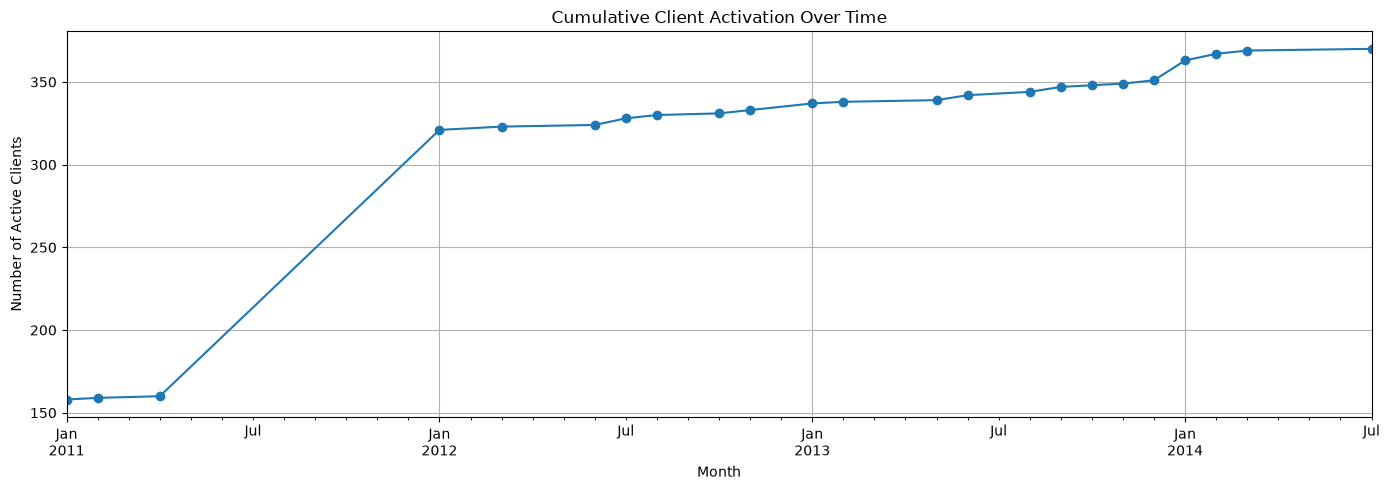

In [20]:
client_activation.cumsum().plot(
    figsize=(14, 5),
    marker="o"
)

plt.title("Cumulative Client Activation Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Active Clients")
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
CHUNK_SIZE = 10_000

aggregate_chunks = []

for chunk_number, chunk in enumerate(
    pd.read_csv(
        RAW_DATA_PATH,
        sep=";",
        decimal=",",
        chunksize=CHUNK_SIZE,
    ),
    start=1,
):
    timestamps = pd.to_datetime(chunk.iloc[:, 0])

    client_data = chunk.iloc[:, 1:]

    # Aggregate the 370 clients at each 15-minute timestamp
    total_demand = client_data.sum(axis=1)

    aggregate_chunk = pd.Series(
        total_demand.to_numpy(),
        index=timestamps,
        name="total_demand",
    )

    aggregate_chunks.append(aggregate_chunk)

    print(f"Processed {chunk_number} chunks")

total_demand_15min = pd.concat(aggregate_chunks)

print("\nShape:", total_demand_15min.shape)
print("Start:", total_demand_15min.index.min())
print("End:", total_demand_15min.index.max())
print("Missing values:", total_demand_15min.isna().sum())

Processed 1 chunks
Processed 2 chunks
Processed 3 chunks
Processed 4 chunks
Processed 5 chunks
Processed 6 chunks
Processed 7 chunks
Processed 8 chunks
Processed 9 chunks
Processed 10 chunks
Processed 11 chunks
Processed 12 chunks
Processed 13 chunks
Processed 14 chunks
Processed 15 chunks

Shape: (140256,)
Start: 2011-01-01 00:15:00
End: 2015-01-01 00:00:00
Missing values: 0


In [22]:
total_demand_15min.describe()

count    140256.000000
mean     195556.942526
std       84259.360145
min         342.595509
25%      131128.411567
50%      167856.513526
75%      248834.303388
max      452652.595567
Name: total_demand, dtype: float64

In [23]:
total_demand_15min.head(20)

Unnamed: 0
2011-01-01 00:15:00    68513.115338
2011-01-01 00:30:00    69180.304361
2011-01-01 00:45:00    69364.850573
2011-01-01 01:00:00    68350.480660
2011-01-01 01:15:00    66166.874303
2011-01-01 01:30:00    64843.191940
2011-01-01 01:45:00    66017.963844
2011-01-01 02:00:00    65345.513794
2011-01-01 02:15:00    65567.578171
2011-01-01 02:30:00    65765.802247
2011-01-01 02:45:00    67245.325321
2011-01-01 03:00:00    68103.694184
2011-01-01 03:15:00    65008.593923
2011-01-01 03:30:00    66561.918281
2011-01-01 03:45:00    66631.927876
2011-01-01 04:00:00    65307.528619
2011-01-01 04:15:00    64336.195865
2011-01-01 04:30:00    64751.684853
2011-01-01 04:45:00    65458.801364
2011-01-01 05:00:00    64744.291655
Name: total_demand, dtype: float64

In [24]:
total_demand_15min.tail(20)

Unnamed: 0
2014-12-31 19:15:00    208667.712264
2014-12-31 19:30:00    199475.540664
2014-12-31 19:45:00    182099.203461
2014-12-31 20:00:00    174057.969223
2014-12-31 20:15:00    172011.267752
2014-12-31 20:30:00    162736.944607
2014-12-31 20:45:00    158998.588312
2014-12-31 21:00:00    155332.414972
2014-12-31 21:15:00    155302.636576
2014-12-31 21:30:00    160449.157503
2014-12-31 21:45:00    153905.565556
2014-12-31 22:00:00    150568.543355
2014-12-31 22:15:00    148365.634998
2014-12-31 22:30:00    144894.923782
2014-12-31 22:45:00    137023.682306
2014-12-31 23:00:00    132288.754939
2014-12-31 23:15:00    128543.516567
2014-12-31 23:30:00    127478.208411
2014-12-31 23:45:00    125641.710272
2015-01-01 00:00:00    124214.199215
Name: total_demand, dtype: float64

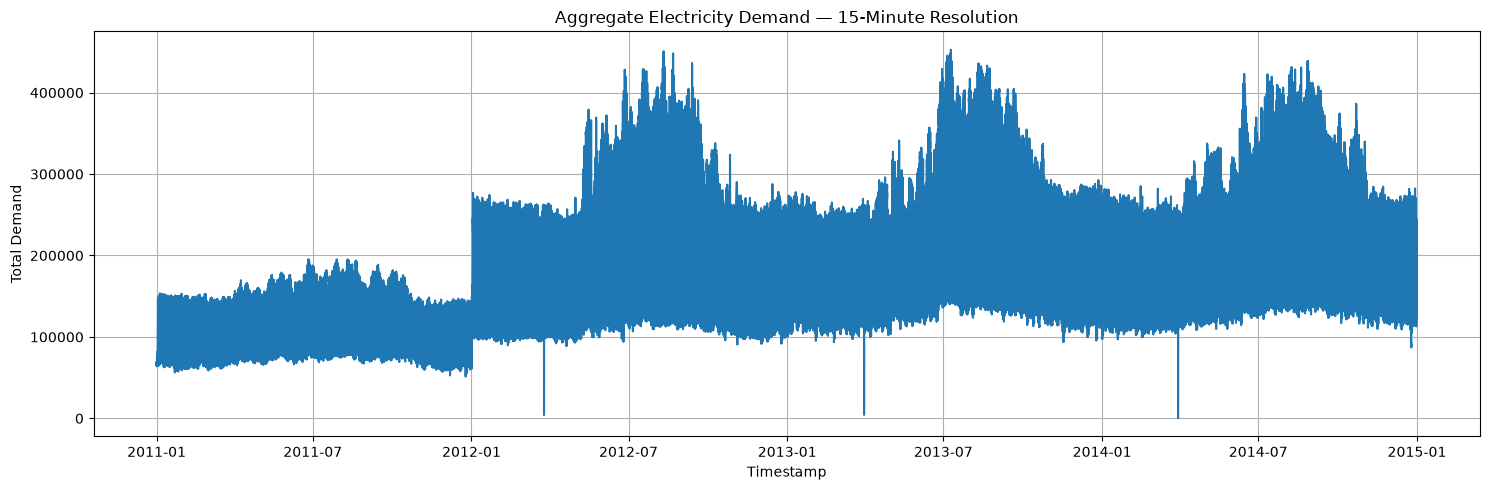

In [26]:
plt.figure(figsize=(15, 5))

plt.plot(total_demand_15min.index, total_demand_15min.values)

plt.title("Aggregate Electricity Demand — 15-Minute Resolution")
plt.xlabel("Timestamp")
plt.ylabel("Total Demand")
plt.grid(True)

plt.tight_layout()
plt.show()

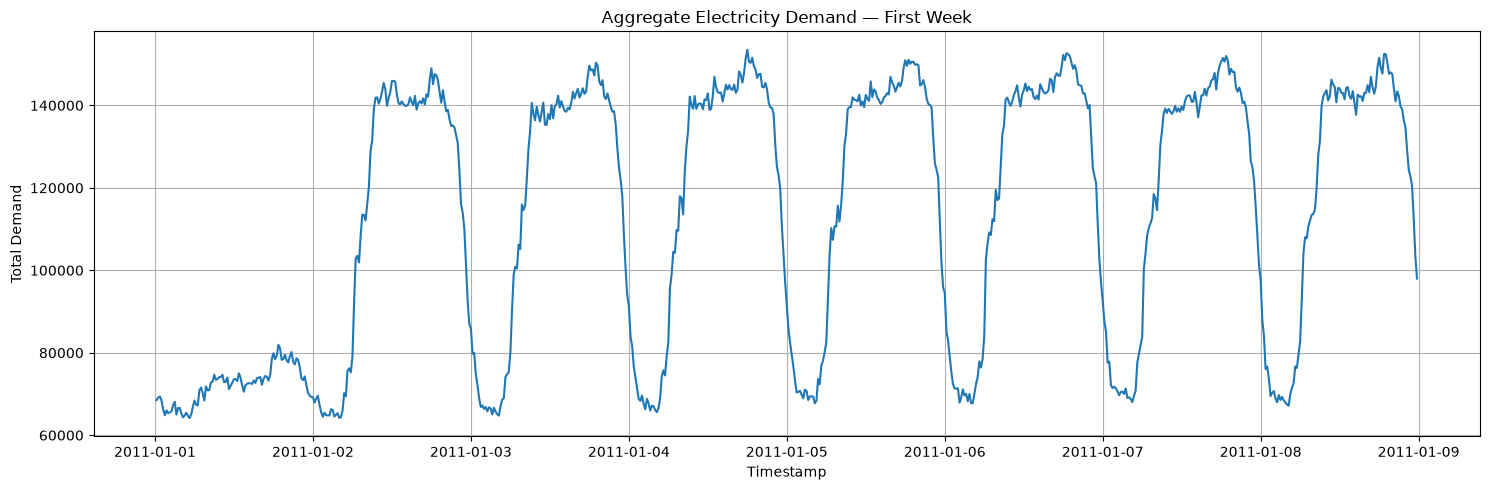

In [27]:
first_week = total_demand_15min.loc[
    "2011-01-01":"2011-01-08"
]

plt.figure(figsize=(15, 5))

plt.plot(first_week.index, first_week.values)

plt.title("Aggregate Electricity Demand — First Week")
plt.xlabel("Timestamp")
plt.ylabel("Total Demand")
plt.grid(True)

plt.tight_layout()
plt.show()

In [38]:
# Shift timestamps backward by 15 minutes so that each
# observation is assigned to the hour it represents.

shifted_demand = total_demand_15min.copy()
shifted_demand.index = shifted_demand.index - pd.Timedelta(minutes=15)

hourly_resampled = shifted_demand.resample("1h").agg(
    ["mean", "count"]
)

hourly_demand = hourly_resampled.loc[
    hourly_resampled["count"] == 4,
    "mean"
]

print("15-minute observations:", len(total_demand_15min))
print("Complete hourly observations:", len(hourly_demand))
print("Missing hourly values:", hourly_demand.isna().sum())

print("\nStart:", hourly_demand.index.min())
print("End:", hourly_demand.index.max())

15-minute observations: 140256
Complete hourly observations: 35064
Missing hourly values: 0

Start: 2011-01-01 00:00:00
End: 2014-12-31 23:00:00


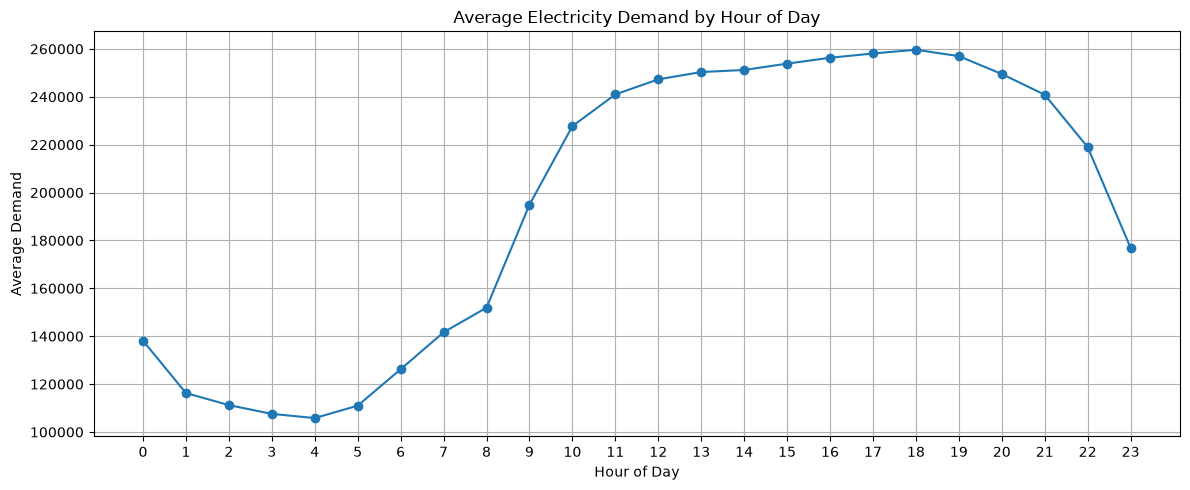

In [34]:
hourly_profile = hourly_demand.groupby(
    hourly_demand.index.hour
).mean()

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_profile.index,
    hourly_profile.values,
    marker="o"
)

plt.title("Average Electricity Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand")
plt.xticks(range(24))
plt.grid(True)

plt.tight_layout()
plt.show()

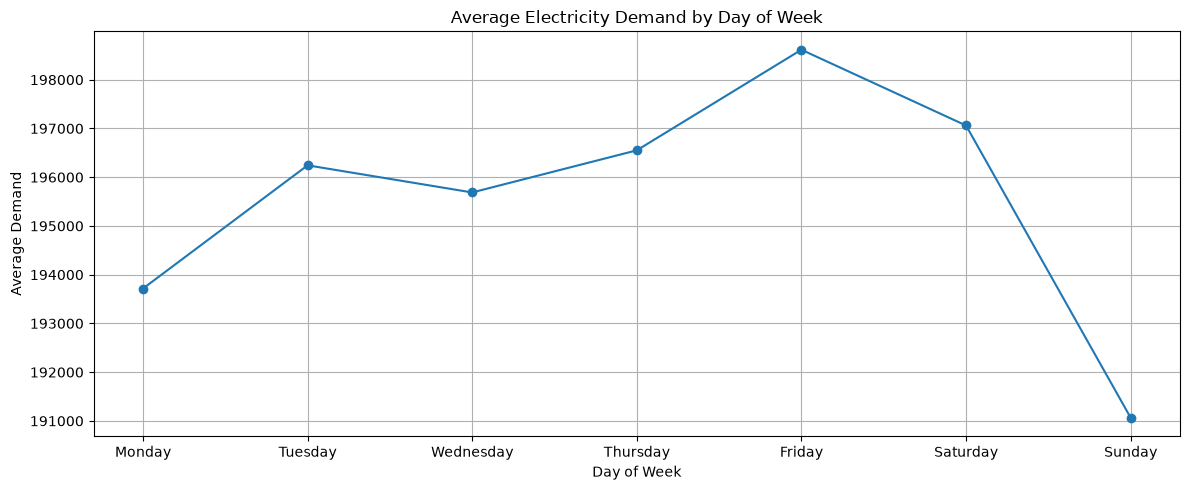

In [35]:
weekly_profile = hourly_demand.groupby(
    hourly_demand.index.dayofweek
).mean()

day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

plt.figure(figsize=(12, 5))

plt.plot(
    day_names,
    weekly_profile.values,
    marker="o"
)

plt.title("Average Electricity Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand")
plt.grid(True)

plt.tight_layout()
plt.show()

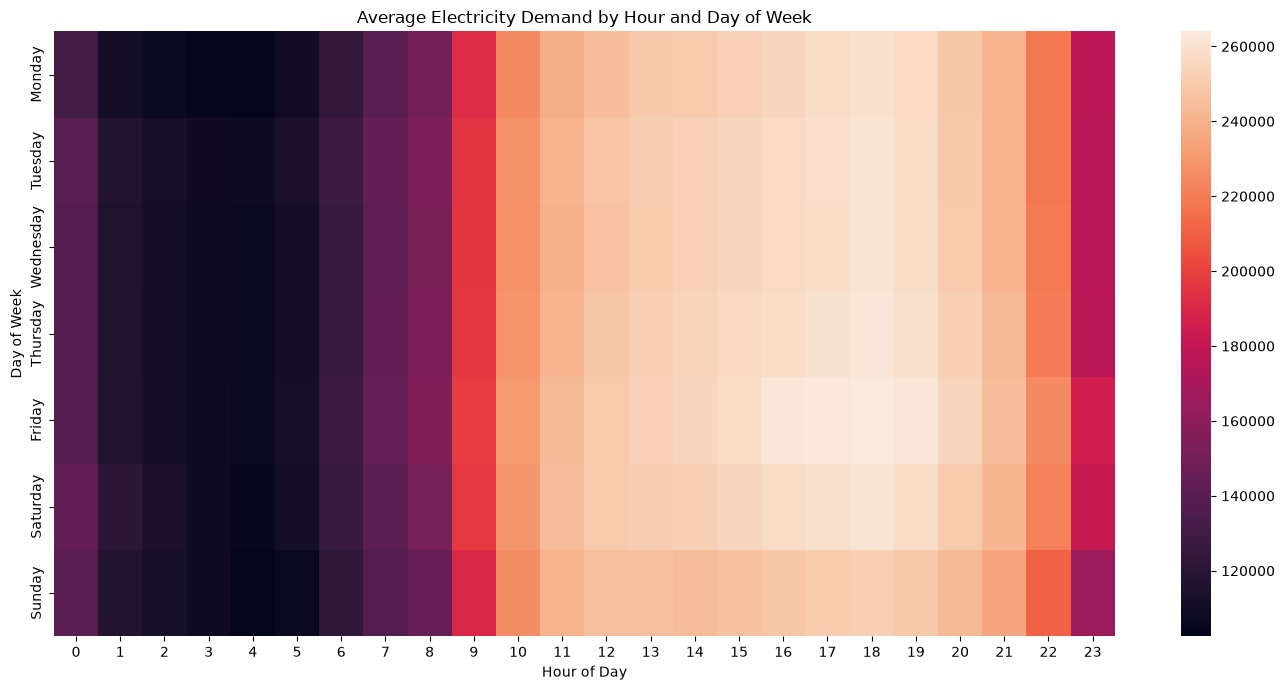

In [36]:
hour_day_profile = hourly_demand.groupby([
    hourly_demand.index.dayofweek,
    hourly_demand.index.hour
]).mean()

profile_matrix = hour_day_profile.unstack(level=0)

profile_matrix.columns = day_names

plt.figure(figsize=(14, 7))

sns.heatmap(profile_matrix.T)

plt.title("Average Electricity Demand by Hour and Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.tight_layout()
plt.show()

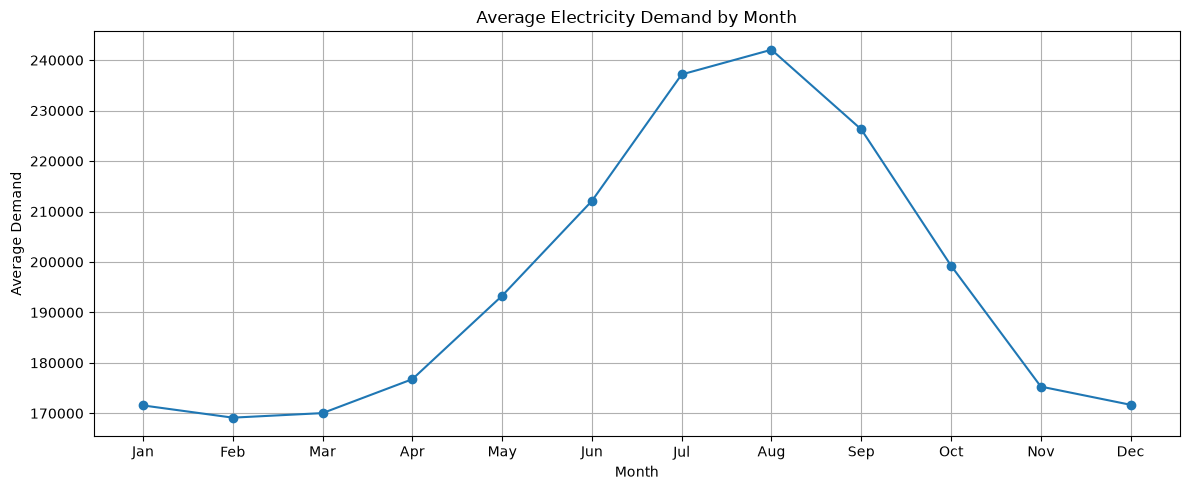

In [37]:
monthly_profile = hourly_demand.groupby(
    hourly_demand.index.month
).mean()

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(12, 5))

plt.plot(
    month_names,
    monthly_profile.values,
    marker="o"
)

plt.title("Average Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand")
plt.grid(True)

plt.tight_layout()
plt.show()